## Title: customer sgmentation whosale employee turnover

Objective: Analyze employee data to understand which factors (satisfaction, working hours, time at company, salary, department) are related to employees leaving the company.

Dataset: employee records with features such as satisfaction_level, last_evaluation, number_project, average_monthly_hours, time_spend_company, Work_accident, left, promotion_last_5years, sales (department), and salary.


## Importing Libraries

The required libraries, namely Pandas, NumPy, Matplotlib, and Seaborn, were imported to perform data manipulation, numerical computations, and data visualization. These libraries help in cleaning the dataset, analyzing patterns, and creating graphs for better understanding of employee turnover.

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#pandas → Used for loading and manipulating datasets.
#numpy → Used for numerical computations.
#matplotlib → Used to create graphs and visualizations.
#snsn → Used for advanced statistical plots.

## Installing Required Libraries

The following command is used to install the required Python libraries for the project:

```bash
pip install seaborn pandas matplotlib numpy
```

- **Pandas**: Used for loading, cleaning, and manipulating the dataset.
- **NumPy**: Used for numerical and mathematical computations.
- **Matplotlib**: Used for creating graphs and visualizations.
- **Seaborn**: Used for advanced statistical plots and data visualization.

These libraries are essential for performing data preprocessing, exploratory data analysis (EDA), and building machine learning models for employee turnover prediction.

In [141]:
pip install seaborn pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## Loading the Dataset and Display 
The Employee Turnover dataset was loaded into a DataFrame and the first few records were displayed to gain an initial understanding of the dataset's structure, features, and sample data.

In [142]:
#Loads the dataset into a DataFrame.
df = pd.read_csv(r"C:\Users\boyin\Downloads\archive.csv")
# information about the data set
#head() → Displays the first few rows.
df.head()



,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [143]:
df.tail(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


In [144]:
# to fnd how many rows and columns we have to use shape function
#shape → Gives the number of rows and columns.
df.shape

(14999, 10)

In [145]:
df.columns
#columns → Displays all column names.
# it prints the column names of the data set which are the features.

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')

In [146]:
df.info()
# it prints information about the data set, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Handling Missing and Duplicate Values

The dataset was checked for missing values and duplicate records to ensure data quality and consistency. Any missing or repeated records were removed to create a clean and reliable dataset for accurate analysis and machine learning model building.

In [147]:
#checking for null values in the data set
#Helps identify columns that need cleaning.
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [148]:
(df == "").sum()
# to find empty strings in the data set

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [149]:
# To check for duplicate rows in the dataset, we can use the duplicated() function . It returns a boolean series indicating wheather each row is a duplicate or not.We can then use the sum() functionto count the number of duplicate rows in the dataset.
df.duplicated().sum()

df[df.duplicated(subset=['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'], keep=False)]


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [150]:
# remove the duplcates from the dataset using drop_duplicate() function.
df.drop_duplicates(inplace=True)
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high
11998,0.33,0.65,3,172,10,0,0,1,marketing,high


In [151]:
df.describe()
# provide statistical summary of the data set
#Shows mean, median, minimum, maximum, and standard deviation.
#Helps understand the distribution of numerical features.

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


The `df.describe()` function is used to generate a statistical summary of all numerical columns in the dataset. It provides important measures such as count, mean, standard deviation, minimum value, maximum value, and quartiles (25%, 50%, and 75%). From the Employee Turnover dataset, we found that there are **14,999 records** for every numerical feature, confirming that there are no missing values. The average employee satisfaction level is around **0.61**, the average monthly working hours are approximately **201 hours**, and employees spend an average of **3.5 years** in the company. The summary statistics also help us identify the range and spread of each feature and check for possible outliers or unusual values. This step gives a better understanding of the data distribution before performing exploratory data analysis and building machine learning models.


## Feature and Target Variable Separation

The dataset was divided into input features and the target variable. The target variable represents whether an employee left the company or stayed, while the remaining columns were used as input features to predict employee turnover.

In [152]:
#X contains input features.
#Y contains the target variable.
X = df.drop('left', axis=1) 
Y = df['left']
# here left means it is the target feature like if the employee left the company or not.
#left - 1 means the employee left the company
#left - 0 means the employee stayed in the company
print(X.shape,Y.shape)

(11991, 9) (11991,)


In this step, the dataset is divided into input features (`X`) and the target variable (`Y`). The `left` column is selected as the target variable because our goal is to predict whether an employee will leave the company or stay. A value of `1` in the `left` column indicates that the employee has left the company, while `0` indicates that the employee is still working in the company. By using `X = df.drop('left', axis=1)`, all the remaining columns become input features that help in making the prediction. The `print(X.shape, Y.shape)` statement is used to verify the dimensions after splitting the data. For this dataset, `X.shape` is `(14999, 9)`, which means there are 14,999 records and 9 input features, while `Y.shape` is `(14999,)`, indicating that there are 14,999 target values corresponding to each employee record.

<Axes: xlabel='left', ylabel='count'>

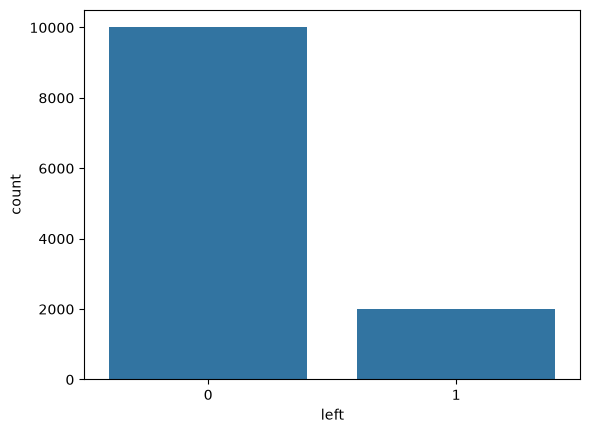

In [153]:
sns.countplot(x='left', data=df)

The sns.countplot(x='left', data=df) chart shows the distribution of employees who stayed in the company versus those who left. From the graph, we can observe that around 10,000 employees have a value of 0, meaning they stayed in the company, while around 2,000 employees have a value of 1, meaning they left the company. This indicates that the majority of employees remained with the company and only a smaller portion left.

## Outlier Detection

Outlier detection was performed to identify extreme values that differ significantly from the majority of the data. These unusual values can affect statistical analysis and the performance of machine learning models. Boxplots were used to visualize the distribution of numerical features and detect potential outliers. In this dataset, only the `time_spend_company` column contained a few outliers, which represent employees who have spent many years in the company. Since these values are genuine employee records and not data entry errors, they were retained in the dataset.

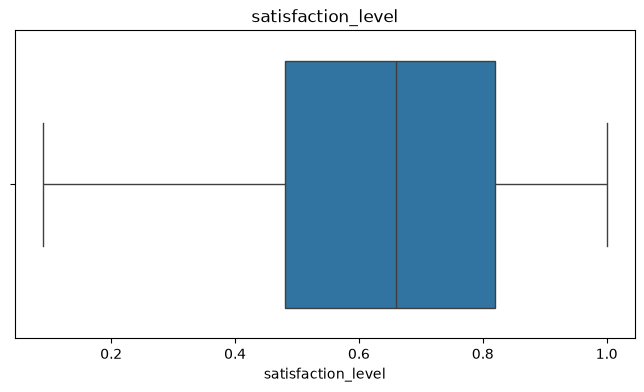

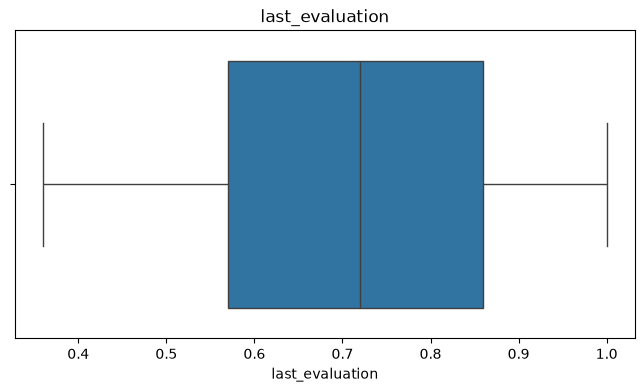

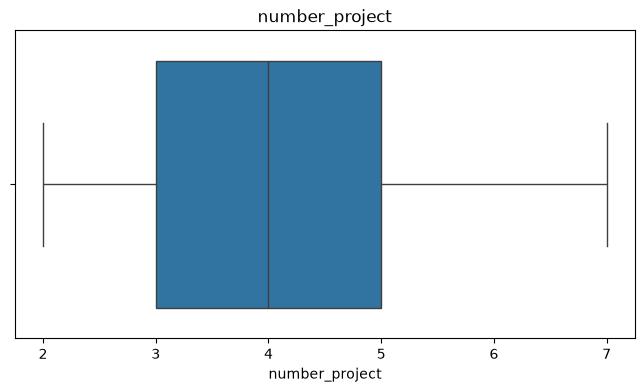

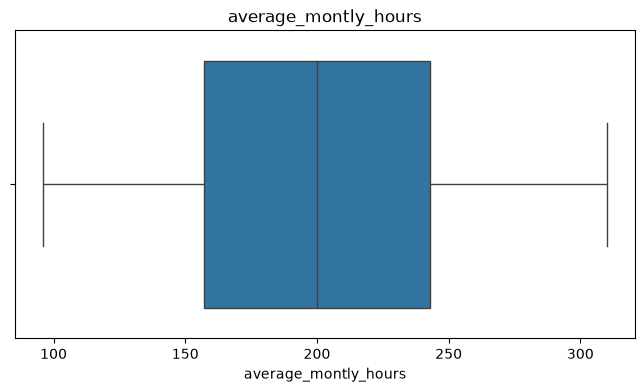

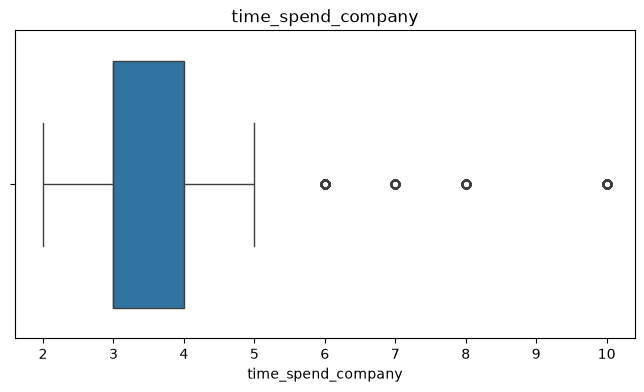

In [154]:
num_cols = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company'
]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Removing Outliers

Outlier analysis was performed on all numerical features to identify extreme values that could affect the analysis and machine learning model performance. The boxplots showed that `satisfaction_level`, `last_evaluation`, `number_project`, and `average_montly_hours` do not contain any significant outliers. However, the `time_spend_company` column contained a few outliers representing employees who had spent significantly more years in the company. These outliers were identified and removed using the Interquartile Range (IQR) method to reduce the impact of extreme values and improve the quality of the dataset.

In [155]:
num_cols = [

    'time_spend_company'
]

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print(df.shape)

(11167, 10)


Outliers were detected using boxplots and the Interquartile Range (IQR) method. The `time_spend_company` column contained a few extreme values corresponding to employees who had spent many years in the company. Since these values represent real employee records and not data entry errors, they were retained in the dataset to preserve important business information. Removing these outliers could result in the loss of valuable patterns that may help in predicting employee turnover.

what is IQR method
The Interquartile Range (IQR) method was used to detect outliers in the dataset. IQR measures the spread of the middle 50% of the data by calculating the difference between the third quartile (Q3) and the first quartile (Q1). Any values lying below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR` are considered outliers. This method is effective because it is not affected by extreme values and works well for non-normal data distributions.


## Analysis

### Analysis of Satisfaction Level vs Employee Turnover

The boxplot compares the satisfaction levels of employees who stayed in the company (`left = 0`) and those who left the company (`left = 1`).

- Employees who stayed in the company have a higher median satisfaction level of around **0.70**.
- Employees who left the company have a much lower median satisfaction level of around **0.40**.
- Most employees who left the company had satisfaction levels between **0.10 and 0.50**.

This analysis indicates a strong relationship between employee satisfaction and turnover. Employees with lower satisfaction levels are more likely to leave the company, while employees with higher satisfaction levels tend to stay. Therefore, `satisfaction_level` is an important feature for predicting employee attrition.

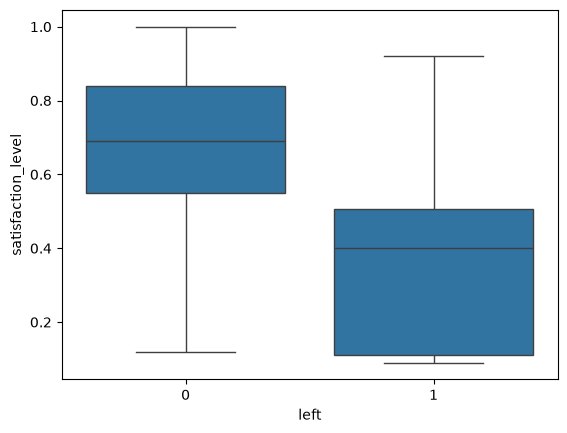

In [156]:
#box plot to visualize the distribution of satisfaction_level based on wheather the employee left the company or not. 
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.show()

### Analysis of Last Evaluation vs Employee Turnover

The boxplot compares the performance evaluation scores of employees who stayed in the company (`left = 0`) and those who left the company (`left = 1`).

- Employees who stayed have a median evaluation score of around **0.72**.
- Employees who left have a slightly higher median evaluation score of around **0.77**.
- The evaluation scores of employees who left are spread over a wider range.

This indicates that employee turnover is not directly related to low performance. In fact, some employees who left had relatively high evaluation scores. Therefore, `last_evaluation` alone may not be a strong predictor of employee turnover, but it can become important when combined with other features such as satisfaction level, working hours, and number of projects.

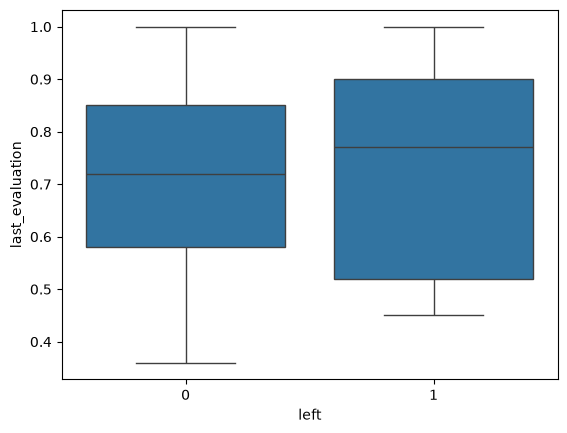

In [157]:
#box plot to see the distribution of lastevaluation based on wheather the employee left the company or not
sns.boxplot(x='left', y='last_evaluation', data=df)
plt.show()

## Analysis of Last Evaluation vs Employee Turnover

The boxplot shows that employees who left the company had slightly higher evaluation scores than those who stayed. This indicates that employee turnover is not directly related to poor performance, as some high-performing employees also left the company. Therefore, `last_evaluation` may contribute to predicting employee turnover when combined with other features.

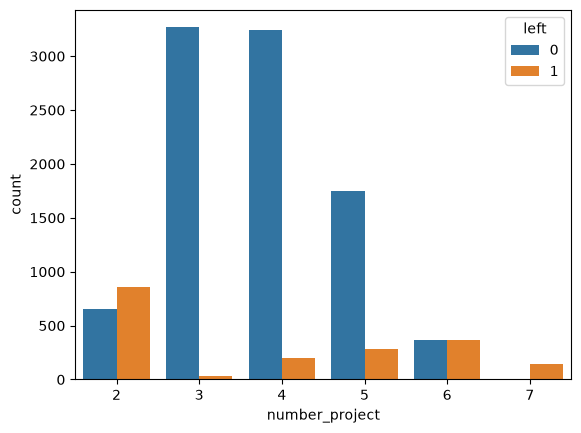

In [158]:
sns.countplot(x='number_project', hue='left', data=df)
plt.show()

## Analysis of Average Monthly Hours vs Employee Turnover

The boxplot compares the average monthly working hours of employees who stayed in the company (`left = 0`) and those who left (`left = 1`).

The analysis shows that employees who left the company generally worked more hours than those who stayed. The median monthly working hours of employees who left are higher, indicating that excessive workload may be one of the reasons for employee turnover.

Therefore, `average_montly_hours` is an important feature in predicting employee attrition, as employees with higher working hours are more likely to leave the company.

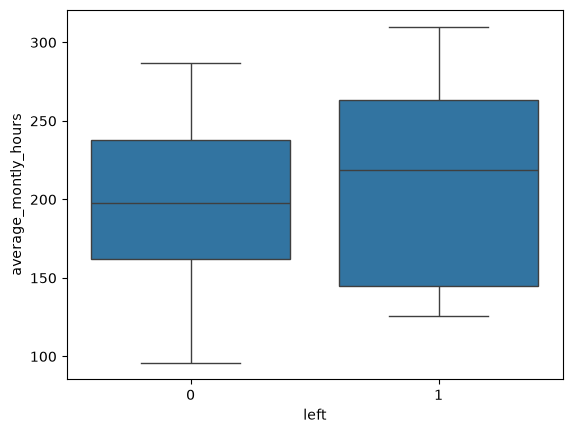

In [159]:
sns.boxplot(x='left', y='average_montly_hours', data=df)
plt.show()

## Analysis of Time Spent in Company vs Employee Turnover

The count plot shows the relationship between the number of years employees spent in the company and whether they stayed or left.

The analysis indicates that most employees who stayed in the company had worked for **2 to 3 years**. However, the number of employees leaving the company increases for employees who have spent **4 and 5 years** in the organization.

This suggests that employee turnover is higher among employees with longer tenure, possibly due to factors such as lack of career growth, promotions, or job satisfaction. Therefore, `time_spend_company` is an important feature for predicting employee attrition.

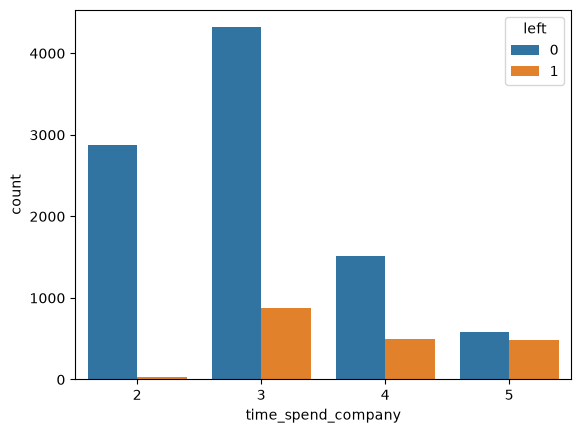

In [160]:
sns.countplot(x='time_spend_company', hue='left', data=df)
plt.show()

## Analysis of Salary vs Employee Turnover

The count plot shows the relationship between employee salary levels and whether they stayed in the company or left.

The analysis indicates that employees with **low and medium salaries** have a higher tendency to leave the company, whereas employees with **high salaries** are less likely to leave. The number of employees leaving is significantly lower in the high-salary category.

This suggests that salary plays an important role in employee retention. Employees receiving lower salaries may be more likely to leave the company in search of better opportunities. Therefore, `salary` is an important feature for predicting employee turnover.

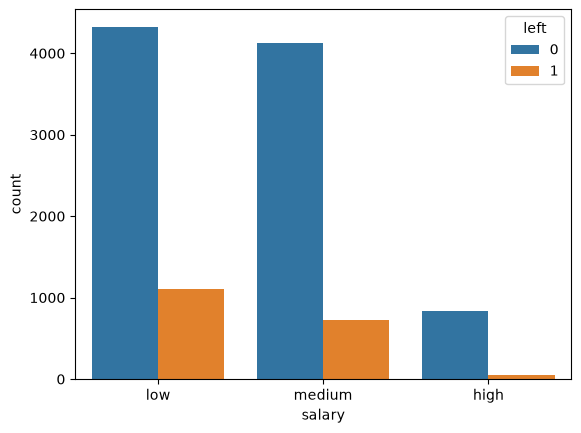

In [161]:
sns.countplot(x='salary', hue='left', data=df)
plt.show()

## Analysis of Department vs Employee Turnover

The count plot shows the distribution of employees who stayed and left across different departments.

The analysis indicates that the **Sales, Technical, and Support** departments have the highest number of employees leaving the company. On the other hand, departments such as **Management, Product Management, and Accounting** have relatively lower employee turnover.

This suggests that employee attrition varies across departments and may be influenced by factors such as workload, job responsibilities, and work environment. Therefore, the `sales` (department) feature is an important predictor of employee turnover.

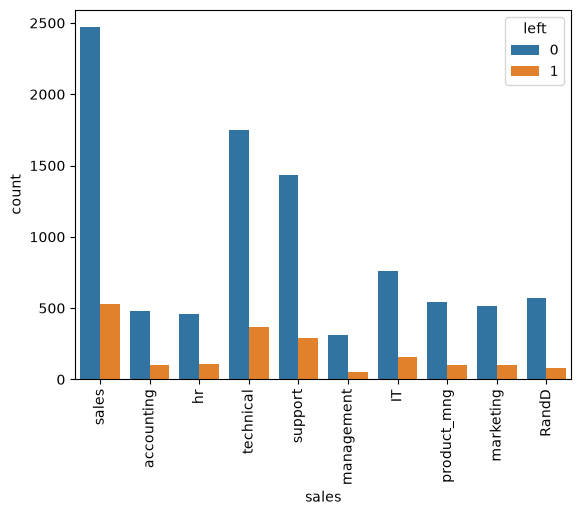

In [162]:
sns.countplot(x='sales', hue='left', data=df)
plt.xticks(rotation=90)
plt.show()

## Analysis of Promotion vs Employee Turnover

The count plot shows the relationship between employee promotions in the last five years and whether they stayed in the company or left.

The analysis indicates that most employees did not receive a promotion in the last five years. Among these employees, a significant number left the company. In contrast, employees who received a promotion had a much lower turnover rate.

This suggests that a lack of promotions may contribute to employee dissatisfaction and increase the likelihood of employees leaving the company. Therefore, `promotion_last_5years` is an important feature for predicting employee turnover.

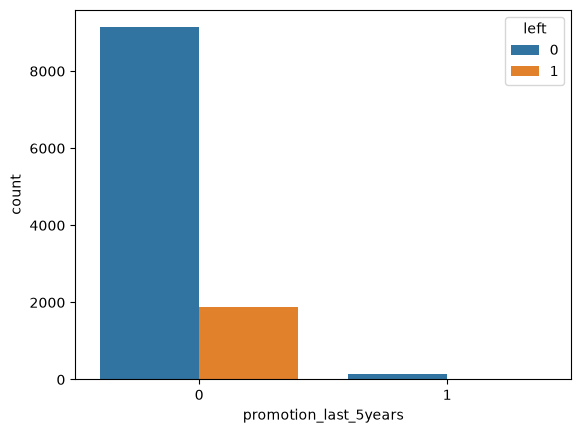

In [163]:
sns.countplot(x='promotion_last_5years', hue='left', data=df)
plt.show()

## Analysis of Work Accident vs Employee Turnover

The count plot shows the relationship between work accidents and employee turnover.

The analysis indicates that most employees did not experience a work accident. Among these employees, a higher number left the company. In contrast, employees who had experienced a work accident showed a lower turnover rate.

This suggests that work accidents do not appear to be a major reason for employee attrition. Therefore, `Work_accident` has a relatively weaker impact on predicting employee turnover compared to features such as satisfaction level and salary.

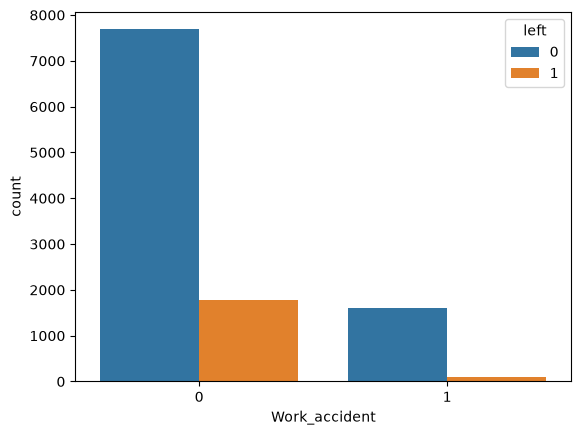

In [164]:
sns.countplot(x='Work_accident', hue='left', data=df)
plt.show()

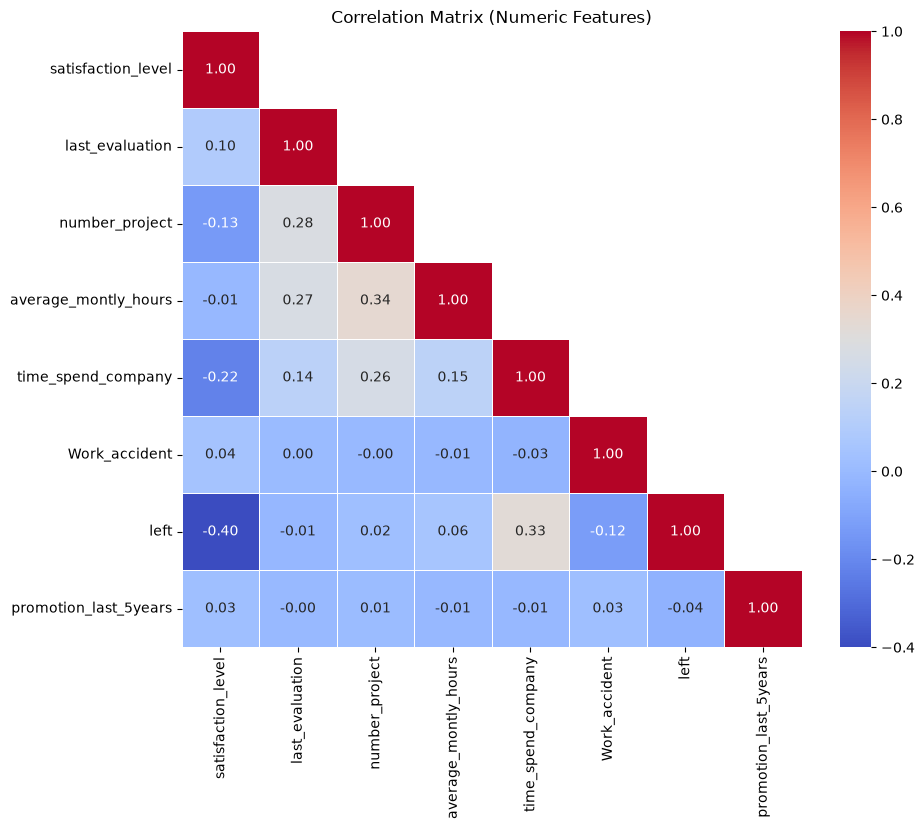

In [168]:
corr = df.corr(numeric_only=True)

# Hide only the upper triangle, keep the diagonal
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Matrix (Numeric Features)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()